In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/11011
1


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [11]:
i_stepsize = 11
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  11 0.4500000000000001 0.42500000000000016
-------  22 0.5000000000000002 0.4750000000000002
-------  33 0.5000000000000002 0.5250000000000002
-------  44 0.47500000000000014 0.5750000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  66 0.5250000000000001 0.6500000000000004
-------  77 0.4500000000000001 0.7000000000000004
-------  88 0.5500000000000003 0.7250000000000004
-------  99 0.4250000000000001 0.7750000000000005
-------  110 0.5000000000000002 0.8000000000000005
-------  121 0.5750000000000002 0.8250000000000005
-------  132 0.4500000000000001 0.8750000000000006
-------  143 0.5250000000000001 0.9000000000000006


In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13311.435770934964
Gradient descend method:  None
RUN  0 , total integrated cost =  13311.435770934964
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21565.177588309605
Gradient descend method:  None
RUN  0 , total integrated cost =  21565.177588309605
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  33 0.5000000000000002 0.525000000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13311.435770934964
Gradient descend method:  None
RUN  1 , total integrated cost =  10890.491617241318
RUN  2 , total integrated cost =  10837.169444736965
RUN  3 , total integrated cost =  10835.168757223082
RUN  4 , total integrated cost =  10835.121044085192
RUN  5 , total integrated cost =  10835.105127810264
RUN  6 , total integrated cost =  10835.103982705808
RUN  7 , total integrated cost =  10835.10344369588
RUN  8 , total integrated cost =  10835.102007061087
RUN  9 , total integrated cost =  10835.10193700818
RUN  10 , total integrated cost =  10835.101194027395
RUN  11 , total integrated cost =  10835.094623849853
RUN  12 , total integrated cost =  10835.0871897014
RUN  13 , total integrated cost =  10835.085363672919
RUN  14 , total integrated cost =  10835.084843302704
RUN  15 , total integrated cost =  10835.070222624117

ERROR:root:Problem in initial value trasfer


RUN  20 , total integrated cost =  10835.067829979236
Control only changes marginally.
RUN  22 , total integrated cost =  10835.067829979234
Improved over  22  iterations in  19.990344436839223  seconds by  18.603312096226233  percent.
Problem in initial value trasfer:  Vmean_exc -56.655644463925704 -56.65610771170719
weight =  12.285512171971773
set cost params:  1.0 12.285512171971773 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  11024.50883999481
Gradient descend method:  None
RUN  1 , total integrated cost =  11009.42713085338
RUN  2 , total integrated cost =  11009.40543118315
RUN  3 , total integrated cost =  11009.40142849215
RUN  4 , total integrated cost =  11009.40142849214


ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  11009.401428492138
RUN  6 , total integrated cost =  11009.401428492138
Control only changes marginally.
RUN  6 , total integrated cost =  11009.401428492138
Improved over  6  iterations in  0.6289385315030813  seconds by  0.13703478061414387  percent.
Problem in initial value trasfer:  Vmean_exc -56.65673096097361 -56.65717012033119
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21565.177588309605
Gradient descend method:  None
RUN  1 , total integrated cost =  19308.166179867298
RUN  2 , total integrated cost =  19285.157432284617
RUN  3 , total integrated cost =  19284.265565320995
RUN  4 , total integrated cost =  19284.208379405085
RUN  5 , total integrated cost =  19284.190839539893
RUN  6 , total integrated cost =  19284.173649654746
RUN  7 , total integrated cost =  19284.156780820304
RUN  8 , total integrated cost =  19284.1564675905
RUN  

...

RUN  5 , total integrated cost =  9543.136241510972
RUN  6 , total integrated cost =  9543.136241510972
Control only changes marginally.
RUN  6 , total integrated cost =  9543.136241510972
Improved over  6  iterations in  0.6396982111036777  seconds by  0.0030988254275143845  percent.
Problem in initial value trasfer:  Vmean_exc -56.64734016255451 -56.64747028132378
-------  143 0.5250000000000001 0.9000000000000006
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23430.768838654094
Gradient descend method:  None
RUN  1 , total integrated cost =  22766.740851309107
RUN  2 , total integrated cost =  22763.10985027842
RUN  3 , total integrated cost =  22762.98059852099
RUN  4 , total integrated cost =  22762.763772254057
RUN  5 , total integrated cost =  22762.61184219236
RUN  6 , total integrated cost =  22762.344780688032
RUN  7 , total integrated cost =  22762.215760896004
RUN  8 , total integrated cost =  22762.03848633454
RUN  9 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  58 , total integrated cost =  22759.2633360825
Improved over  58  iterations in  4.245326552540064  seconds by  2.865913223742794  percent.
Problem in initial value trasfer:  Vmean_exc -56.69969172842485 -56.699746848258584
weight =  10.295047116708295
set cost params:  1.0 10.295047116708295 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22768.12366587413
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  22768.12366587413
Control only changes marginally.
RUN  1 , total integrated cost =  22768.12366587413
Improved over  1  iterations in  0.33474473655223846  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69969172842485 -56.699746848258584


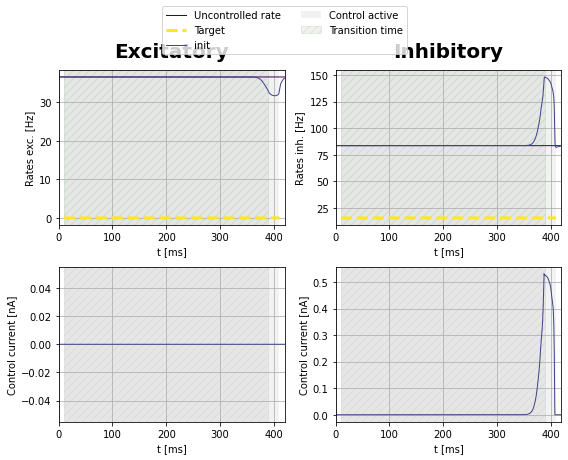

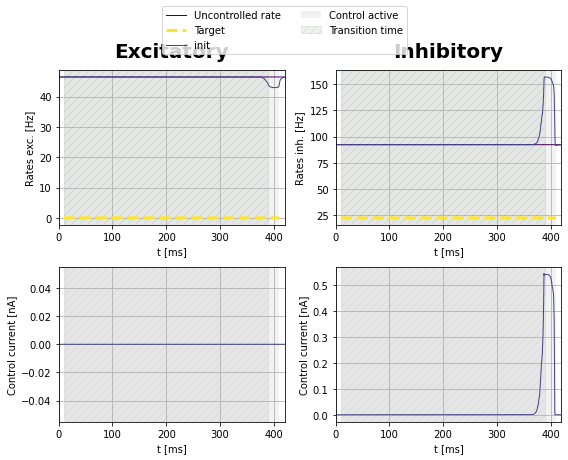

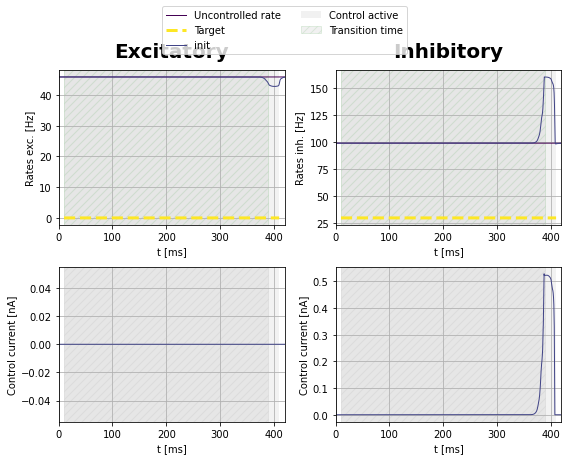

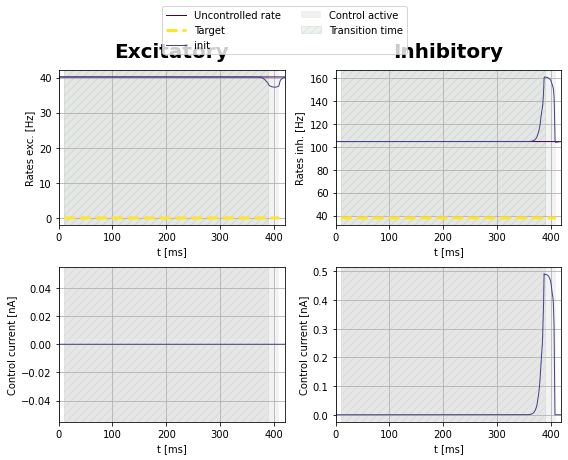

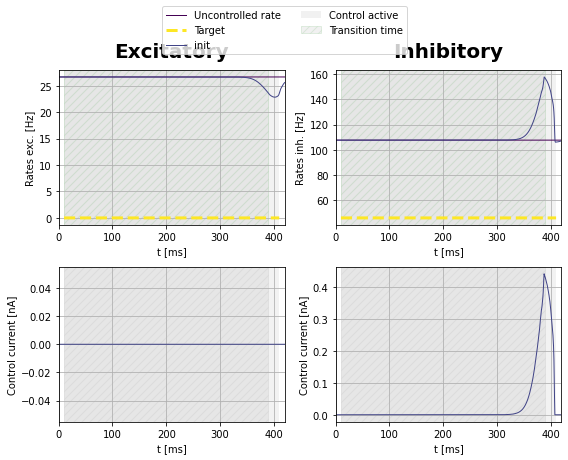

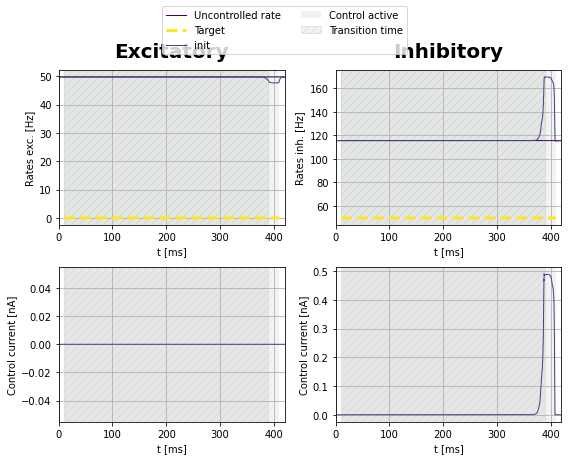

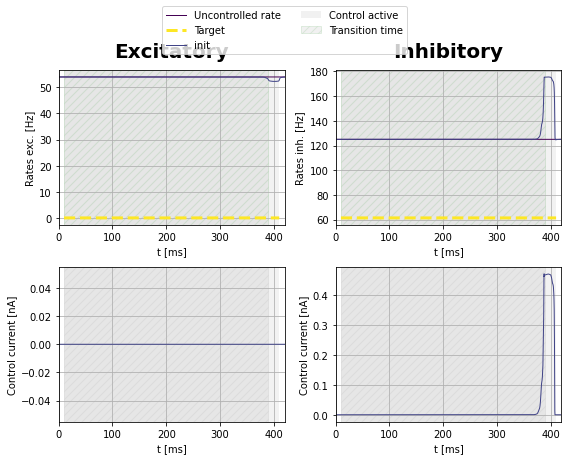

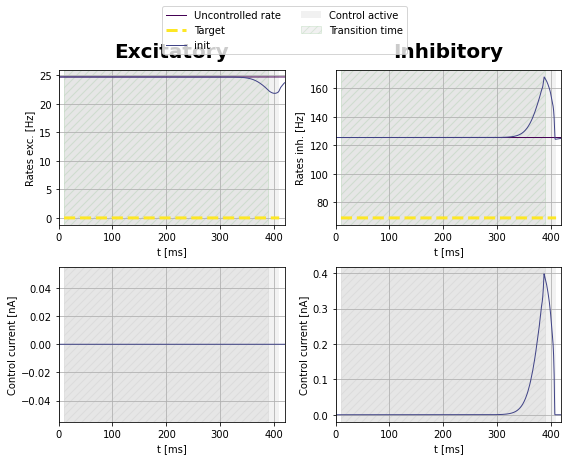

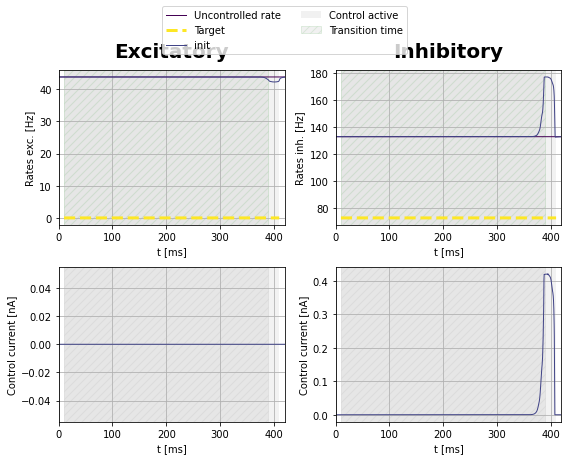

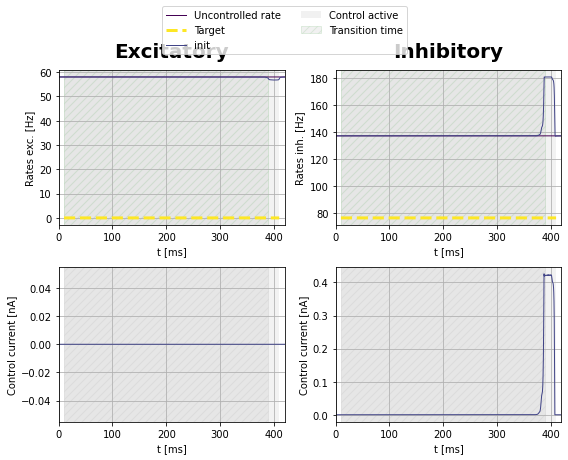

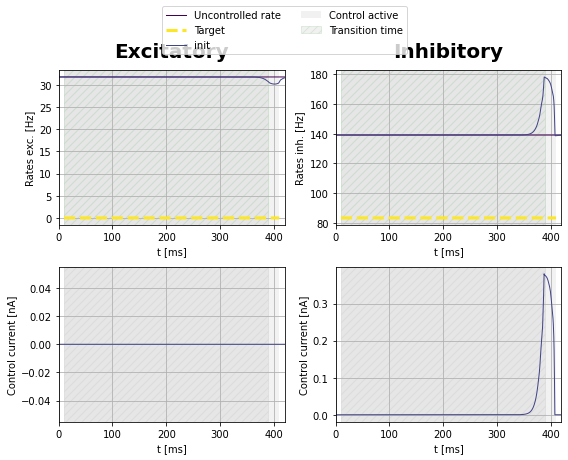

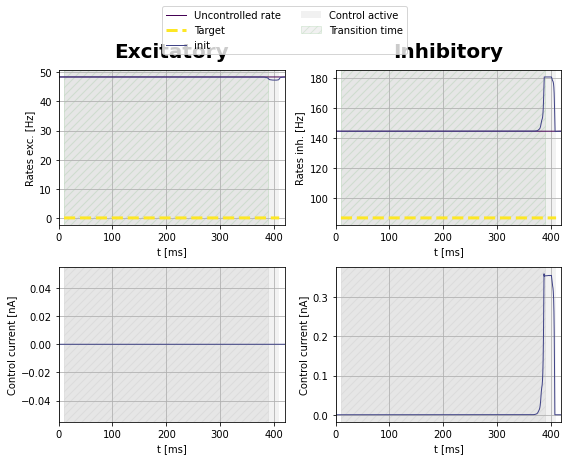

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 147
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  11 0.4500000000000001 0.42500000000000016
[0] []
closest index  0
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  Tru

ERROR:root:Problem in initial value trasfer


RUN  15 , total integrated cost =  10835.090002194194
Control only changes marginally.
RUN  15 , total integrated cost =  10835.090002194194
Improved over  15  iterations in  1.257904289290309  seconds by  21.527458688961133  percent.
Problem in initial value trasfer:  Vmean_exc -56.65553814643417 -56.65599989542239
weight =  12.285487031708358
set cost params:  1.0 12.285487031708358 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  11024.67776226007
Gradient descend method:  None
RUN  1 , total integrated cost =  11009.519559750715
RUN  2 , total integrated cost =  11009.480805668067
RUN  3 , total integrated cost =  11009.476209418015
RUN  4 , total integrated cost =  11009.474940813287
RUN  5 , total integrated cost =  11009.474823671762
RUN  6 , total integrated cost =  11009.474394040846
RUN  7 , total integrated cost =  11009.470815629662
RUN  8 , total integrated cost =  11009.465782974661
RUN  9 , total integrated cost =  11009.460484361814
RUN  10 , 

ERROR:root:Problem in initial value trasfer


RUN  13 , total integrated cost =  11009.460145210931
Control only changes marginally.
RUN  13 , total integrated cost =  11009.460145210931
Improved over  13  iterations in  1.6058870926499367  seconds by  0.13803230695079094  percent.
Problem in initial value trasfer:  Vmean_exc -56.65673438496668 -56.65717347444526
-------  22 0.5000000000000002 0.4750000000000002
[0] []
closest index  0
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22074.20654354059
Gradient descend method:  None
RUN  1 , total integrated cost =  19571.49781243192
RUN  2 , total integrated cost =  19298.967434880025
RUN  3 , total integrated cost =  19285.027349793632
RUN  4 , total integrated cost =  19284.50177417004
RUN  5 , total integrated cost =  19284.378674892447
RUN  6 , total integrated cost =  19284.32114676354
RUN  7 , total integrated cost =  19284.270163831905
RUN  8 , total integrated cost =  19284.22024815219
RUN  9 , tot

...

RUN  6 , total integrated cost =  9543.125598810218
RUN  7 , total integrated cost =  9543.125598810218
Control only changes marginally.
RUN  7 , total integrated cost =  9543.125598810218
Improved over  7  iterations in  0.6201969515532255  seconds by  0.00326475214224331  percent.
Problem in initial value trasfer:  Vmean_exc -56.64734656536512 -56.6474762524108
-------  143 0.5250000000000001 0.9000000000000006
[0] []
closest index  0
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23948.039285860887
Gradient descend method:  None
RUN  1 , total integrated cost =  22912.804079538917
RUN  2 , total integrated cost =  22879.900564906955
RUN  3 , total integrated cost =  22801.4763569933
RUN  4 , total integrated cost =  22795.588624712782
RUN  5 , total integrated cost =  22784.459993725075
RUN  6 , total integrated cost =  22783.0184740647
RUN  7 , total integrated cost =  22780.438686244583
RUN  8 , total in

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  222 , total integrated cost =  22760.78121172734
Improved over  222  iterations in  15.321996096521616  seconds by  4.957642084855422  percent.
Problem in initial value trasfer:  Vmean_exc -56.69957740717491 -56.69963872524628
weight =  10.294360558495043
set cost params:  1.0 10.294360558495043 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22770.283332506522
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  22770.283332506522
Control only changes marginally.
RUN  1 , total integrated cost =  22770.283332506522
Improved over  1  iterations in  0.19517320580780506  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69957740717491 -56.69963872524628
------------------------------------------------------------
-------------------- 1
------------------------------------------------------------
found solution:  [0]
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
-------  11 0.4500000000000001 0.42500000000000016
closest index  -1
set cost params:  1.0 10.0 0.0
all options tried already
-------  22 0.5000000000000002 0.4750000000000002
closest index  -1
set cost params:  1.0 10.0 0.0
all options tried already
-------  33 0.5000000000000002 0.5250000000000002
closest index  -1
set cost params:  1.0 10.0 0.0
all options tried already
-------  44 0.47500000000000014 0.5750000000000003
closest index  -1
set cost params:  1.0

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  11 0.4500000000000001 0.42500000000000016
no convergence
weight =  13.854268000450356
set cost params:  1.0 13.854268000450356 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  11115.437166454665
Gradient descend method:  None
RUN  1 , total integrated cost =  11110.473657099417
RUN  2 , total integrated cost =  11110.447305184645
RUN  3 , total integrated cost =  11110.44542138533
RUN  4 , total integrated cost =  11110.44334555295
RUN  5 , total integrated cost =  11110.443344101874


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  11110.443344101865
RUN  7 , total integrated cost =  11110.443344101865
Control only changes marginally.
RUN  7 , total integrated cost =  11110.443344101865
Improved over  7  iterations in  0.9060812965035439  seconds by  0.04492690910863928  percent.
Problem in initial value trasfer:  Vmean_exc -56.65744900905869 -56.657864937548354
-------  22 0.5000000000000002 0.4750000000000002
no convergence
weight =  11.44692859974568
set cost params:  1.0 11.44692859974568 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19394.059286134223
Gradient descend method:  None
RUN  1 , total integrated cost =  19393.973602327147
RUN  2 , total integrated cost =  19393.954071672513
RUN  3 , total integrated cost =  19393.943734896442
RUN  4 , total integrated cost =  19393.941613761308
RUN  5 , total integrated cost =  19393.941578755777
RUN  6 , total integrated cost =  19393.941578755766


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  19393.941578755763
RUN  8 , total integrated cost =  19393.941578755763
Control only changes marginally.
RUN  8 , total integrated cost =  19393.941578755763
Improved over  8  iterations in  0.7516385093331337  seconds by  0.0006069249182161229  percent.
Problem in initial value trasfer:  Vmean_exc -56.69330688003312 -56.69355127257944
-------  33 0.5000000000000002 0.5250000000000002
no convergence
weight =  11.07007768376412
set cost params:  1.0 11.07007768376412 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19217.22718287355
Gradient descend method:  None
RUN  1 , total integrated cost =  19217.22471546475
RUN  2 , total integrated cost =  19217.221262500658
RUN  3 , total integrated cost =  19217.221249260383
RUN  4 , total integrated cost =  19217.221249033428
RUN  5 , total integrated cost =  19217.221249033413


...

RUN  8 , total integrated cost =  5567.292044196489
RUN  9 , total integrated cost =  5567.292044196489
Control only changes marginally.
RUN  9 , total integrated cost =  5567.292044196489
Improved over  9  iterations in  0.8008746709674597  seconds by  0.011968871283187354  percent.
Problem in initial value trasfer:  Vmean_exc -56.62293620007697 -56.62296023109718
-------  110 0.5000000000000002 0.8000000000000005
no convergence
weight =  4.423783731787172
set cost params:  1.0 4.423783731787172 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18105.92994733062
Gradient descend method:  None
RUN  1 , total integrated cost =  18105.929760576964
RUN  2 , total integrated cost =  18105.92789140481
RUN  3 , total integrated cost =  18105.89501084164
RUN  4 , total integrated cost =  18105.893126715102
RUN  5 , total integrated cost =  18105.893111637975
RUN  6 , total integrated cost =  18105.893111295052
RUN  7 , total integrated cost =  18105.893111284535
RUN 

ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  18105.893111284346
Control only changes marginally.
RUN  10 , total integrated cost =  18105.893111284346
Improved over  10  iterations in  0.8446449730545282  seconds by  0.0002034474140941711  percent.
Problem in initial value trasfer:  Vmean_exc -56.69039433909297 -56.690527040653706
-------  121 0.5750000000000002 0.8250000000000005
converged for  121
-------  132 0.4500000000000001 0.8750000000000006
no convergence
weight =  6.565282153405514
set cost params:  1.0 6.565282153405514 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9384.546649140684
Gradient descend method:  None
RUN  1 , total integrated cost =  9384.540149417911
RUN  2 , total integrated cost =  9384.512364323242
RUN  3 , total integrated cost =  9384.485870351948
RUN  4 , total integrated cost =  9384.443885809496
RUN  5 , total integrated cost =  9384.42574310948
RUN  6 , total integrated cost =  9384.397023802572
RUN  7 , total integrated cost =  938

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  102 , total integrated cost =  9383.234819698506
Improved over  102  iterations in  11.08577785268426  seconds by  0.013978612832602266  percent.
Problem in initial value trasfer:  Vmean_exc -56.64672066922349 -56.646865994965246
-------  143 0.5250000000000001 0.9000000000000006
converged for  143


In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

file found


In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  11208.545992745121
Gradient descend method:  None
RUN  1 , total integrated cost =  144.88483837412596
RUN  2 , total integrated cost =  78.95821459729977
RUN  3 , total integrated cost =  58.33735833496793
RUN  4 , total integrated cost =  53.0439126748698
RUN  5 , total integrated cost =  46.756482379830885
RUN  6 , total integrated cost =  43.98916725328935
RUN  7 , total integrated cost =  40.88596943630559
RUN  8 , total integrated cost =  39.23140690050599
RUN  9 , total integrated cost =  37.58517320200039
RUN  10 , total integrated cost =  36.5104933734905
RUN  11 , total integrated cost =  35.55425994279156
RUN  12 , total integrated cost =  34.861704924571406
RUN  13 , total integrated cost =  34.20163570412148
RUN  14 , total integrated cost =  33.70114233496731
RUN  15 , total integrated cost =  33.24268545881656
RUN  16 ,

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  306 , total integrated cost =  23.426797457198816
Improved over  306  iterations in  87.11424157582223  seconds by  99.79099164626382  percent.
Problem in initial value trasfer:  Vmean_exc -65.88300008882004 -65.88684688450003
weight =  100
set cost params:  1.0 100.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  272.51938768780724
Gradient descend method:  HS
RUN  1 , total integrated cost =  268.8840573649873
RUN  2 , total integrated cost =  268.7296192736568
RUN  3 , total integrated cost =  268.0250465385042
RUN  4 , total integrated cost =  267.5295758671026
RUN  5 , total integrated cost =  267.395573314571
RUN  6 , total integrated cost =  267.3786675181382
RUN  7 , total integrated cost =  267.1583122197779
RUN  8 , total integrated cost =  266.96145617951527
RUN  9 , total integrated cost =  266.77918096717997
RUN  10 , total integrated cost =  266.6948710949757
RUN  11 , total integrated cost =  266.66559526

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  66 , total integrated cost =  265.3828027451255
Improved over  66  iterations in  14.043394099920988  seconds by  2.6187439371679773  percent.
Problem in initial value trasfer:  Vmean_exc -65.36180504954267 -65.37283140395628
weight =  5014.937594011813
set cost params:  1.0 5014.937594011813 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13252.570556401273
Gradient descend method:  None
RUN  1 , total integrated cost =  13119.901711480266
RUN  2 , total integrated cost =  13119.829076187476
RUN  3 , total integrated cost =  13119.734855799266
RUN  4 , total integrated cost =  13119.691750155927
RUN  5 , total integrated cost =  13119.691588943477
RUN  6 , total integrated cost =  13119.690189358982
RUN  7 , total integrated cost =  13119.679169633864
RUN  8 , total integrated cost =  13119.675800996714
RUN  9 , total integrated cost =  13119.675793927996
RUN  10 , total integrated cost =  13119.6757939216
RUN  11 , tot

...

Control only changes marginally.
RUN  224 , total integrated cost =  38.63733888624703
Improved over  224  iterations in  55.947647435590625  seconds by  99.8284182424705  percent.
Problem in initial value trasfer:  Vmean_exc -68.31122023001004 -68.33712450280426
weight =  100
set cost params:  1.0 100.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  738.9008353265199
Gradient descend method:  HS
RUN  1 , total integrated cost =  722.0104823502634
RUN  2 , total integrated cost =  721.7092002081406
RUN  3 , total integrated cost =  721.3112761397845
RUN  4 , total integrated cost =  721.3086201681963
RUN  5 , total integrated cost =  721.2872647747068
RUN  6 , total integrated cost =  721.2871914434633
RUN  7 , total integrated cost =  721.2871914434618
RUN  8 , total integrated cost =  721.2871914434617


ERROR:root:Problem in initial value trasfer


RUN  9 , total integrated cost =  721.2871914434617
Control only changes marginally.
RUN  9 , total integrated cost =  721.2871914434617
Improved over  9  iterations in  1.964081596583128  seconds by  2.3837628868391647  percent.
Problem in initial value trasfer:  Vmean_exc -64.74237719027194 -64.77826666399498
weight =  3247.465953175147
set cost params:  1.0 3247.465953175147 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23242.443626472064
Gradient descend method:  None
RUN  1 , total integrated cost =  22953.82998474509
RUN  2 , total integrated cost =  22952.24386004328
RUN  3 , total integrated cost =  22952.23708332442
RUN  4 , total integrated cost =  22952.18783417868
RUN  5 , total integrated cost =  22952.12024617971
RUN  6 , total integrated cost =  22952.117742905055
RUN  7 , total integrated cost =  22952.109007823376
RUN  8 , total integrated cost =  22952.085495703108
RUN  9 , total integrated cost =  22952.08173029951
RUN  10 , total integr

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  33 , total integrated cost =  15585.319008926608
Improved over  33  iterations in  5.180688034743071  seconds by  32.944576485169335  percent.
Problem in initial value trasfer:  Vmean_exc -56.67460715187043 -56.67637926685185


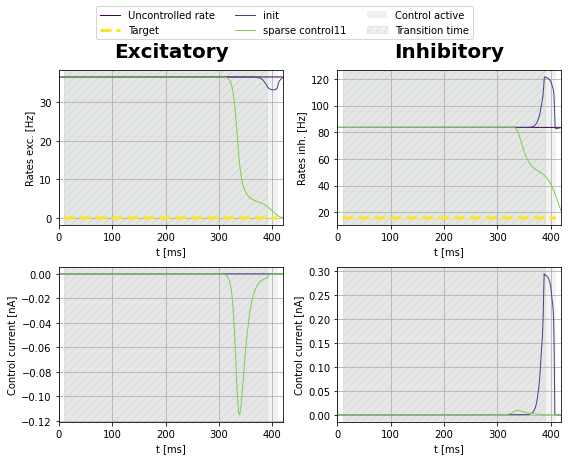

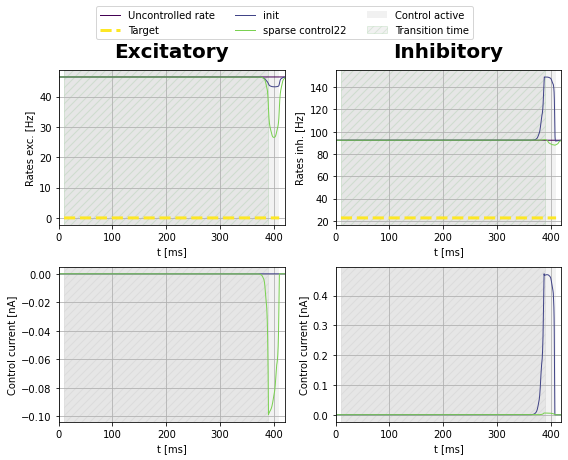

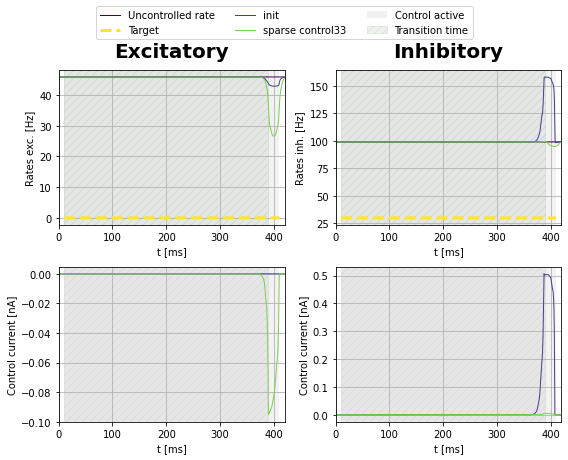

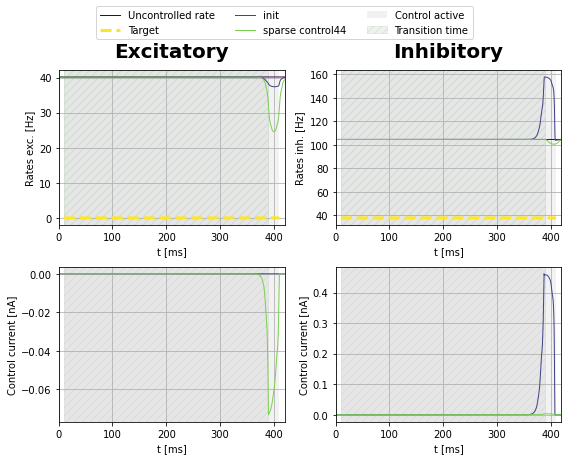

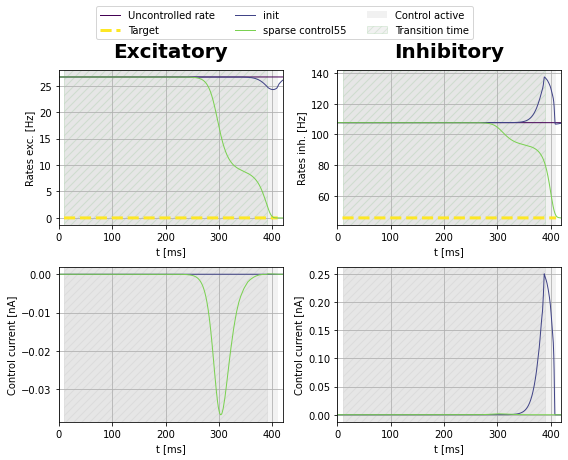

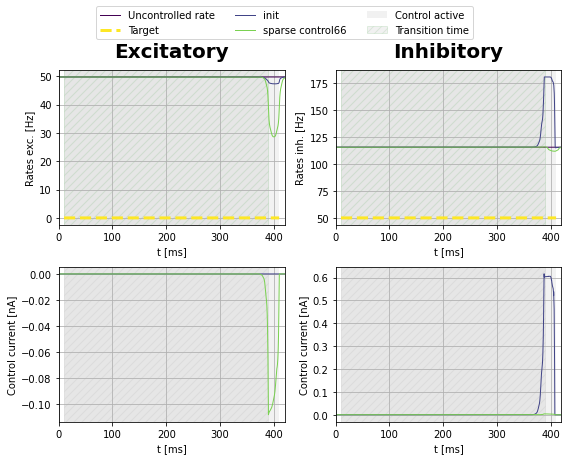

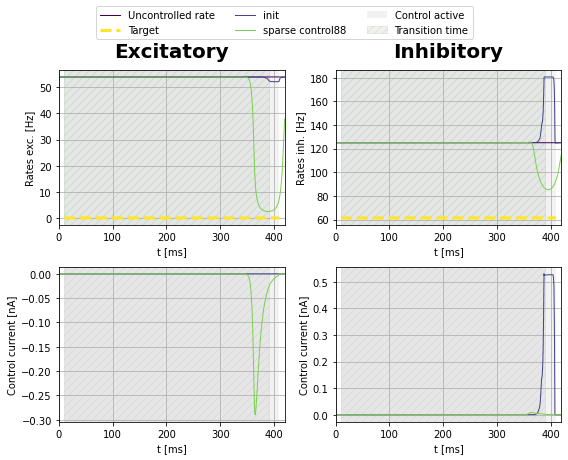

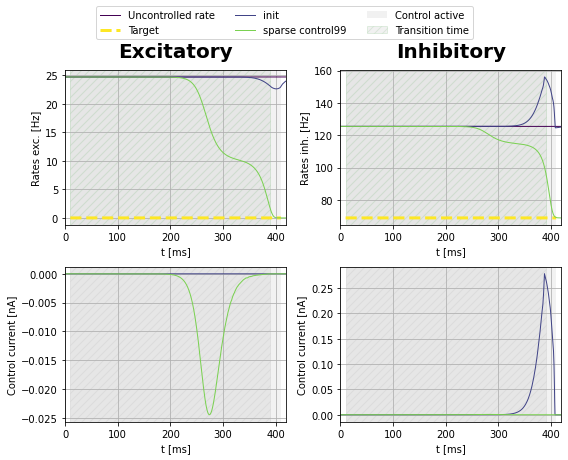

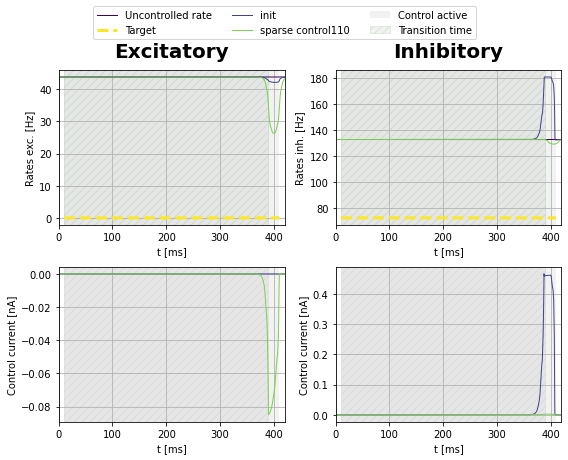

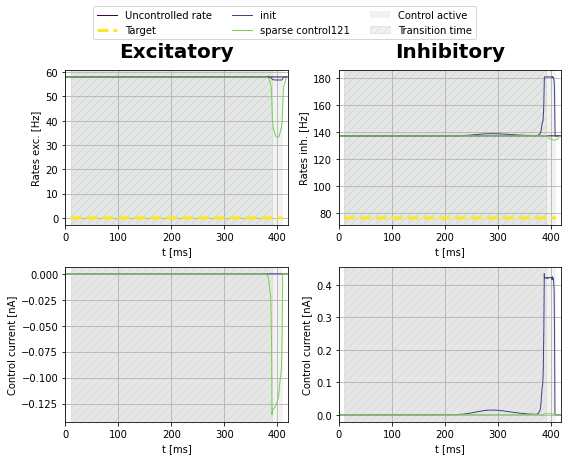

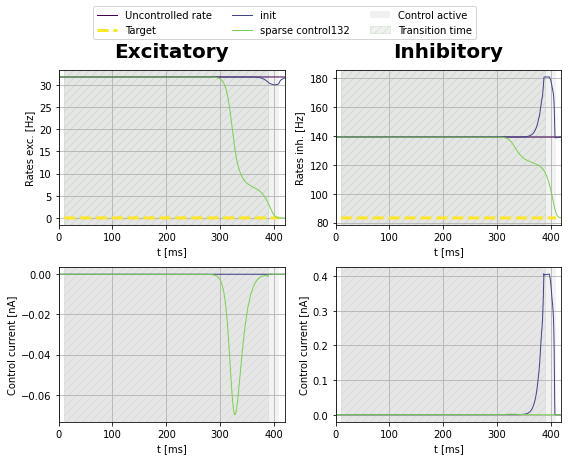

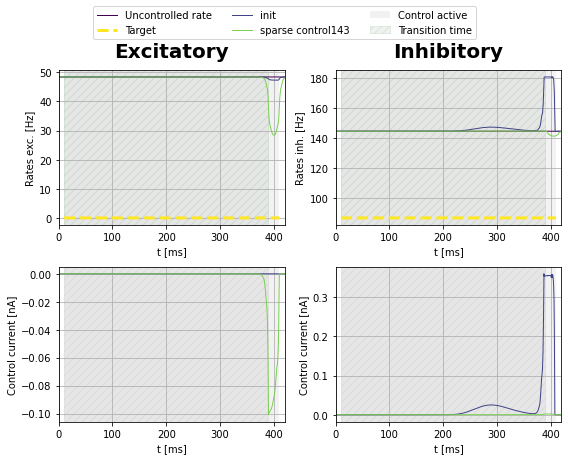

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
no convergence
weight =  5087.236990495325
set cost params:  1.0 5087.236990495325 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13308.278081834042
Gradient descend method:  None
RUN  1 , total integrated cost =  13308.274964470684
RUN  2 , total integrated cost =  13308.274947678612
RUN  3 , total integrated cost =  13308.27494758175
RUN  4 , total integrated cost =  13308.274947572687
RUN  5 , total integrated cost =  13308.274947571776
RUN  6 , total integrated cost =  13308.27494757173
RUN  7 , total integrated cost =  13308.274947571706
RUN  8 , total integrated cost =  13308.2749475717
RUN  9 , total integrated cost =  13308.274947571696
RUN  10 , total integrated c

ERROR:root:Problem in initial value trasfer


RUN  11 , total integrated cost =  13308.274947571692
Control only changes marginally.
RUN  11 , total integrated cost =  13308.274947571692
Improved over  11  iterations in  2.9478895608335733  seconds by  2.3551223762297013e-05  percent.
Problem in initial value trasfer:  Vmean_exc -61.29547435863829 -61.320164554344586
-------  22 0.5000000000000002 0.4750000000000002
no convergence
weight =  4929.359410507622
set cost params:  1.0 4929.359410507622 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17142.171285499146
Gradient descend method:  None
RUN  1 , total integrated cost =  16329.552316439142
RUN  2 , total integrated cost =  16320.169261262292
RUN  3 , total integrated cost =  16320.169261262283
RUN  4 , total integrated cost =  16320.169261262281


ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  16320.169261262281
Control only changes marginally.
RUN  5 , total integrated cost =  16320.169261262281
Improved over  5  iterations in  1.4001215547323227  seconds by  4.795203656214824  percent.
Problem in initial value trasfer:  Vmean_exc -56.68183939483693 -56.68293872864955
-------  33 0.5000000000000002 0.5250000000000002
no convergence
weight =  5076.734828718065
set cost params:  1.0 5076.734828718065 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16767.95280558682
Gradient descend method:  None
RUN  1 , total integrated cost =  16019.189815083595
RUN  2 , total integrated cost =  16010.004833595824
RUN  3 , total integrated cost =  16009.984310040887
RUN  4 , total integrated cost =  16009.984310040882


...

RUN  6 , total integrated cost =  19044.691750074217
Control only changes marginally.
RUN  6 , total integrated cost =  19044.691750074217
Improved over  6  iterations in  1.9655179381370544  seconds by  8.013305082954503e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.69257815918174 -56.69260937501919
-------  121 0.5750000000000002 0.8250000000000005
no convergence
weight =  120840.32845591646
set cost params:  1.0 120840.32845591646 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33312.98049672797
Gradient descend method:  None
RUN  1 , total integrated cost =  33312.952703868184
RUN  2 , total integrated cost =  33312.95264985004
RUN  3 , total integrated cost =  33312.952649850005
RUN  4 , total integrated cost =  33312.95264985


ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  33312.95264985
Control only changes marginally.
RUN  5 , total integrated cost =  33312.95264985
Improved over  5  iterations in  1.4046897497028112  seconds by  8.35916737429443e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.70358212651039 -56.7035698645435
-------  132 0.4500000000000001 0.8750000000000006
converged for  132
-------  143 0.5250000000000001 0.9000000000000006
no convergence
weight =  141892.13839083895
set cost params:  1.0 141892.13839083895 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23209.108206857538
Gradient descend method:  None
RUN  1 , total integrated cost =  23209.08775449456
RUN  2 , total integrated cost =  23209.087745395074
RUN  3 , total integrated cost =  23209.087745395052
RUN  4 , total integrated cost =  23209.08774539504
RUN  5 , total integrated cost =  23209.087745395038


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  23209.087745395038
Control only changes marginally.
RUN  6 , total integrated cost =  23209.087745395038
Improved over  6  iterations in  1.6007744558155537  seconds by  8.816134733535819e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.70023115978819 -56.70025330388268
--------------- 101


In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [False, False], [False, False], [False, False], [True, True], [False, False], [True, True], [True, True], [True, True], [False, False], [False, False], [True, True], [False, False]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

file found


In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  40.6088453001592
Gradient descend method:  None
RUN  1 , total integrated cost =  2.8007340607795386
RUN  2 , total integrated cost =  2.7985408156506737
RUN  3 , total integrated cost =  2.7983129952842476
RUN  4 , total integrated cost =  2.798311565675856
RUN  5 , total integrated cost =  2.79831154452838
RUN  6 , total integrated cost =  2.7983115444624094
RUN  7 , total integrated cost =  2.798311544462409
RUN  8 , total integrated cost =  2.7983115444624045


ERROR:root:Problem in initial value trasfer


RUN  9 , total integrated cost =  2.7983115444624045
Control only changes marginally.
RUN  9 , total integrated cost =  2.7983115444624045
Improved over  9  iterations in  0.7697007302194834  seconds by  93.10910831426317  percent.
Problem in initial value trasfer:  Vmean_exc -65.98163765966272 -65.98457701393188
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21157.922666549104
Gradient descend method:  None
RUN  1 , total integrated cost =  17725.057933867003
RUN  2 , total integrated cost =  17613.689297791665
RUN  3 , total integrated cost =  17609.081869406677
RUN  4 , total integrated cost =  17608.9913616631
RUN  5 , total integrated cost =  17608.971736148866
RUN  6 , total integrated cost =  17608.95281072553
RUN  7 , total integrated cost =  17608.93324153508
RUN  8 , total integrated cost =  17608.916909667594
RUN  9 , total integrated cost =  17608.90754662101
RUN  10 , t

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  39 , total integrated cost =  17608.767241266818
Improved over  39  iterations in  2.7966147027909756  seconds by  16.774593050637904  percent.
Problem in initial value trasfer:  Vmean_exc -56.68911432681337 -56.68951115360005
-------  33 0.5000000000000002 0.5250000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  20671.131961232506
Gradient descend method:  None
RUN  1 , total integrated cost =  17738.405866252797
RUN  2 , total integrated cost =  17605.362188537954
RUN  3 , total integrated cost =  17602.930251685106
RUN  4 , total integrated cost =  17602.768257502717
RUN  5 , total integrated cost =  17602.714774022563
RUN  6 , total integrated cost =  17602.679014108187
RUN  7 , total integrated cost =  17602.651177704753
RUN  8 , total integrated cost =  17602.623369519115
RUN  9 , total integrated cost =  17602.59570002337
RUN  10 , total integrated cost =  17602.57287802601
RUN 

...

Control only changes marginally.
RUN  245 , total integrated cost =  31624.629386937162
Improved over  245  iterations in  17.124968165531754  seconds by  4.1549165200934794  percent.
Problem in initial value trasfer:  Vmean_exc -56.70393839428883 -56.70392525784075
-------  132 0.4500000000000001 0.8750000000000006
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21.943464900257414
Gradient descend method:  None
RUN  1 , total integrated cost =  1.3396841570510554
RUN  2 , total integrated cost =  1.3395166830790404
RUN  3 , total integrated cost =  1.3395165809525786
RUN  4 , total integrated cost =  1.33951658027384
RUN  5 , total integrated cost =  1.3395165802710118
RUN  6 , total integrated cost =  1.3395165802710103
RUN  7 , total integrated cost =  1.33951658027101


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  1.3395165802710098
RUN  9 , total integrated cost =  1.3395165802710096
RUN  10 , total integrated cost =  1.3395165802710096
Control only changes marginally.
RUN  10 , total integrated cost =  1.3395165802710096
Improved over  10  iterations in  0.9180591441690922  seconds by  93.89560132659224  percent.
Problem in initial value trasfer:  Vmean_exc -73.41947555343411 -73.45527044463729
-------  143 0.5250000000000001 0.9000000000000006
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22987.859180896823
Gradient descend method:  None
RUN  1 , total integrated cost =  22048.715319561517
RUN  2 , total integrated cost =  22021.004517832454
RUN  3 , total integrated cost =  22013.51704923392
RUN  4 , total integrated cost =  22011.573216707915
RUN  5 , total integrated cost =  22011.070919399157
RUN  6 , total integrated cost =  22010.807195807403
RUN  7 , total integrated cost =  22010.647850976307
RUN

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  89 , total integrated cost =  21992.65292363661
Improved over  89  iterations in  6.114411439746618  seconds by  4.329268982503777  percent.
Problem in initial value trasfer:  Vmean_exc -56.69877672989371 -56.698885104507276


In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

ERROR:root:Problem in initial value trasfer


--------------- 0
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.7983115444624045
Gradient descend method:  None
RUN  1 , total integrated cost =  2.7983115444624045
Control only changes marginally.
RUN  1 , total integrated cost =  2.7983115444624045
Improved over  1  iterations in  0.16476665064692497  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -65.98163765966272 -65.98457701393188
-------  22 0.5000000000000002 0.4750000000000002
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17608.767241266818
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  17608.767241266818
Control only changes marginally.
RUN  1 , total integrated cost =  17608.767241266818
Improved over  1  iterations in  0.18750316090881824  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.68911432681337 -56.68951115360005
-------  33 0.5000000000000002 0.5250000000000002
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17602.47722407498
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


...

RUN  1 , total integrated cost =  17501.44879724561
Control only changes marginally.
RUN  1 , total integrated cost =  17501.44879724561
Improved over  1  iterations in  0.18495729565620422  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.688677120072064 -56.68887817756902
-------  121 0.5750000000000002 0.8250000000000005
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  31624.629386937162
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  31624.629386937162
Control only changes marginally.
RUN  1 , total integrated cost =  31624.629386937162
Improved over  1  iterations in  0.18754698522388935  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70393839428883 -56.70392525784075
-------  132 0.4500000000000001 0.8750000000000006
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.3395165802710096
Gradient descend method:  None
RUN  1 , total integrated cost =  1.3395165802710096
Control only changes marginally.
RUN  1 , total integrated cost =  1.3395165802710096
Improved over  1  iterations in  0.1658953484147787  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -73.41947555343411 -73.45527044463729
-------  143 0.5250000000000001 0.9000000000000006
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21992.65292

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  21992.65292363661
Control only changes marginally.
RUN  1 , total integrated cost =  21992.65292363661
Improved over  1  iterations in  0.1839150469750166  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69877672989371 -56.698885104507276
--------------- 12
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
converged for  33
-------  44 0.47500000000000014 0.5750000000000003
converged for  44
-------  55 0.4250000000000001 0.6250000000000003
converged for  55
-------  66 0.5250000000000001 0.6500000000000004
converged for  66
-------  88 0.5500000000000003 0.7250000000000004


In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
